In [1]:
import xarray as xr
import xscen as xs
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
import glob
import xclim as xc
from xscen import CONFIG
import cartopy.crs as ccrs
from matplotlib import gridspec
import copy
import xsdba as xa
xs.load_config("config/config_general.yml","config/config_region.yml","config/paths.yml")


import figanos.matplotlib as fg 
fg.utils.set_mpl_style('ouranos')

/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/MPI/gcc12/openmpi4/esmf/8.8.0/lib/python3.11/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
pcat = xs.ProjectCatalog(
    CONFIG['nb']['compcat'],
    create=True,
    project= {
    "title": "compare-catalog",
    "description": "Catalog for comapring DQM and MBCn.",
},
)

In [3]:
# df = xs.parse_directory(
#     directories=[f"{CONFIG['nb']['finaldircomp']}/MBCn/diagnostics/NAM-C3/",
# ],
#     patterns=[
#         "{domain}/{mip_era}_{activity}_{institution}_{source}_{experiment}_{member}_global/{mip_era}_{activity}_{institution}_{source}_{experiment}_{member}_global_NAM-C3_{domain}_{processing_level}.zarr.zip"
#     ],
#     homogenous_info={
#         "bias_adjust_project": "MBCn",
#         "frequency":'fx'
#     },
#     read_from_file=["variable"],
# );
# pcat.update(df)

# df = xs.parse_directory(
#     directories=[f"{CONFIG['nb']['finaldircomp']}/MBCn/diagnostics/NAM-C3/",
# ],
#     patterns=[
#         "{domain}/{processing_level:_}.zarr.zip"
#     ],
#     homogenous_info={
#         "bias_adjust_project": "MBCn",
#         "frequency":'fx'
#     },
#     read_from_file=["variable"],
# );
# pcat.update(df)


# df = xs.parse_directory(
#     directories=[f"{CONFIG['nb']['finaldircomp']}/DQM/diagnostics/CaSRv31/NAM-C3/",
# ],
#     patterns=[
#         "{domain}/{mip_era}_{activity}_{institution}_{source}_{experiment}_{member}_global/{mip_era}_{activity}_{institution}_{source}_{experiment}_{member}_global_NAM-C3_{domain}_{processing_level}.zarr.zip"
#     ],
#     homogenous_info={
#         "bias_adjust_project": "DQM",
#         "frequency":'fx'
#     },
#     read_from_file=["variable"],
# );
# pcat.update(df)

# df = xs.parse_directory(
#     directories=[f"{CONFIG['nb']['finaldircomp']}/DQM/diagnostics/CaSRv31/NAM-C3/",
# ],
#     patterns=[
#         "{domain}/{processing_level:_}.zarr.zip"
#     ],
#     homogenous_info={
#         "bias_adjust_project": "DQM",
#         "frequency":'fx'
#     },
#     read_from_file=["variable"],
# );
# pcat.update(df)



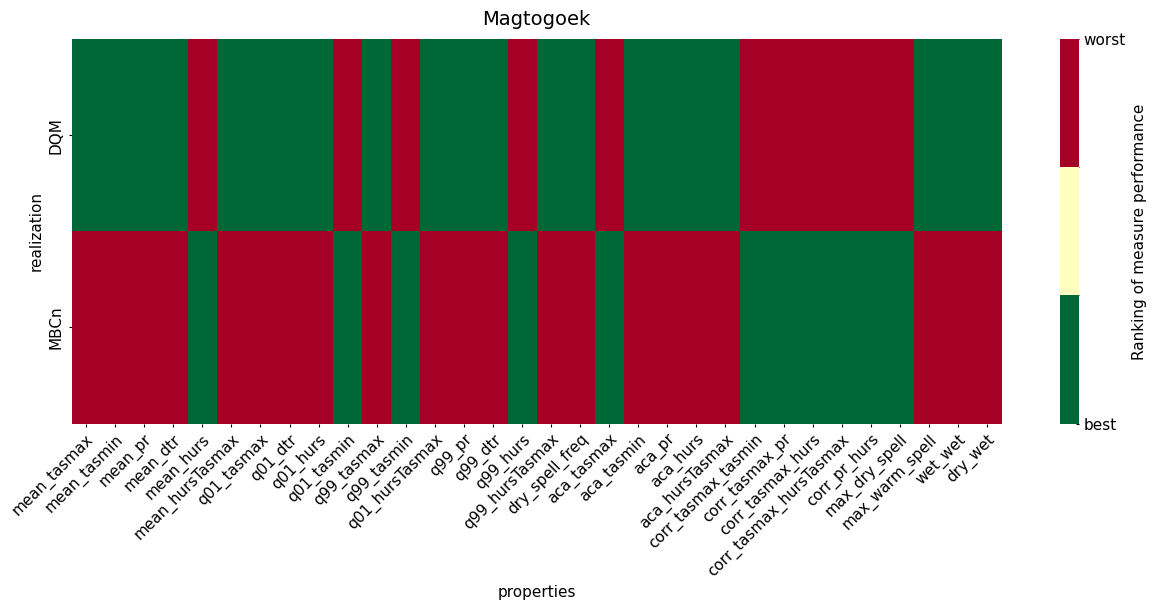

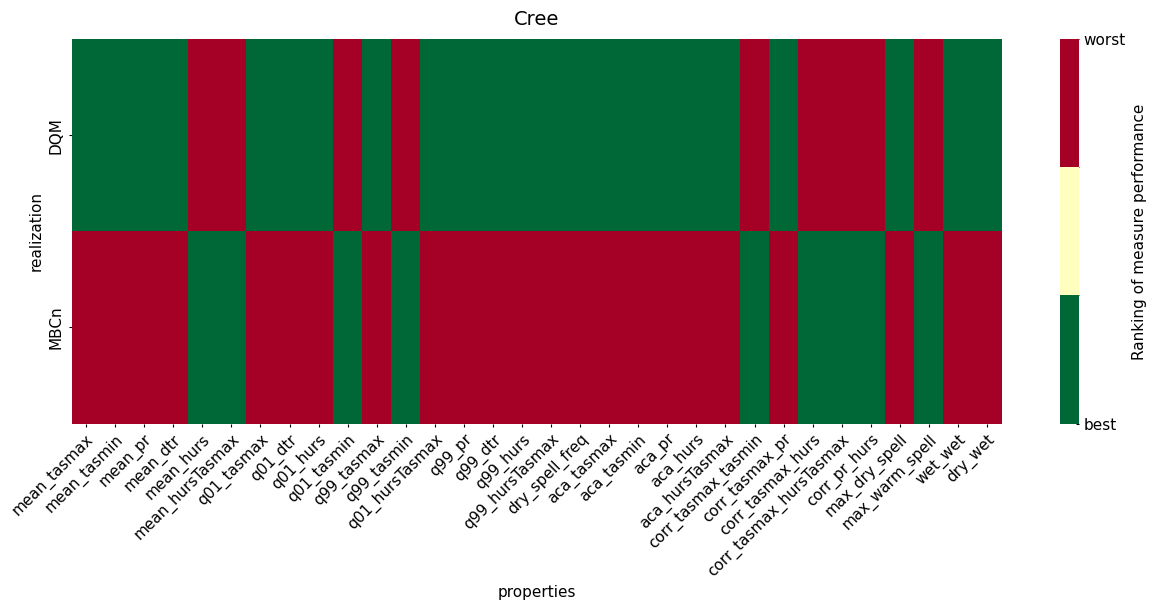

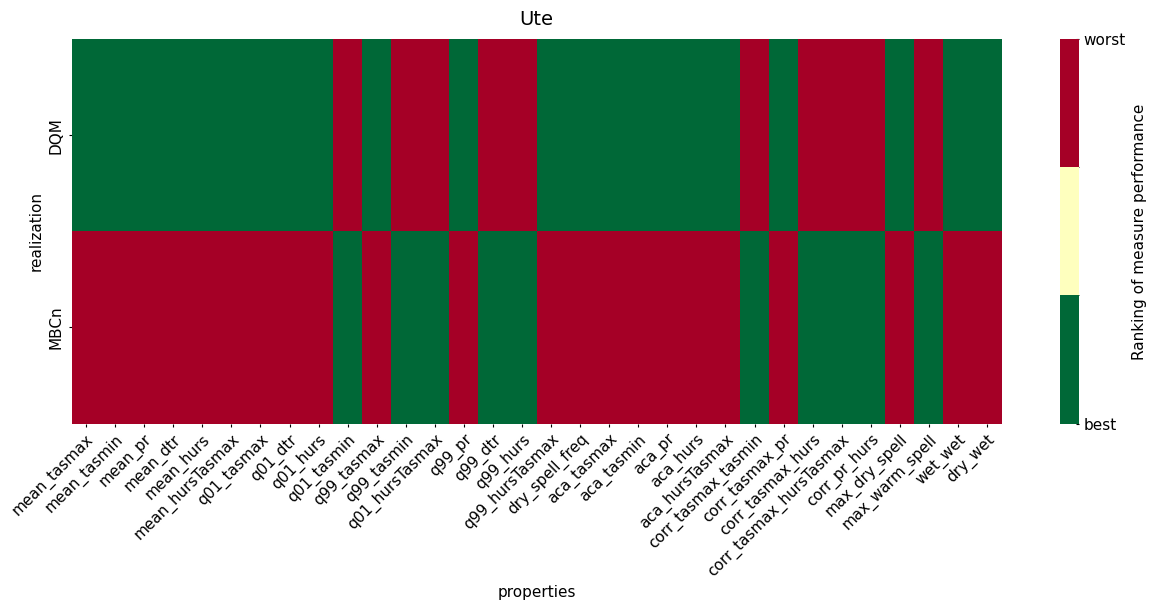

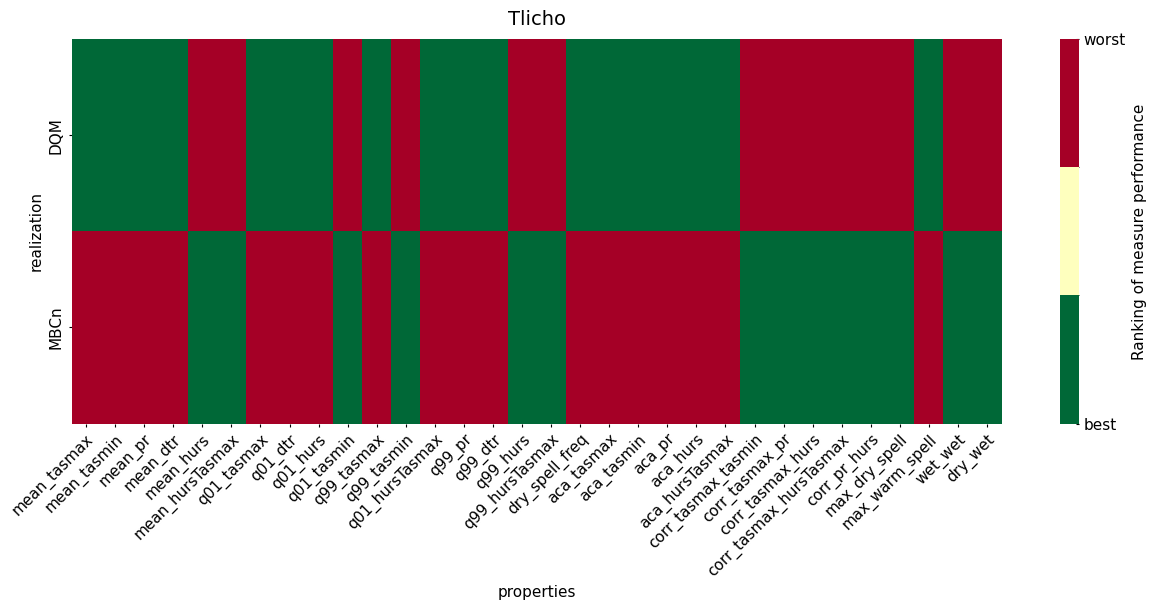

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python

In [4]:

cmap = plt.cm.RdYlGn_r
norm = colors.BoundaryNorm(np.linspace(0, 1, 4), cmap.N)

for r in ['Magtogoek','Cree','Ute','Tlicho']:
    ds_dqm=pcat.search(domain=r, bias_adjust_project='DQM', processing_level='scen-meas').to_dataset()
    ds_mbcn=pcat.search(domain=r, bias_adjust_project='MBCn', processing_level='scen-meas').to_dataset()

    # fix order
    ds_dqm=ds_dqm[["mean_tasmax","mean_tasmin","mean_pr","mean_dtr","mean_hurs","mean_hursTasmax","q01_tasmax","q01_dtr","q01_hurs","q01_tasmin","q99_tasmax","q99_tasmin","q01_hursTasmax","q99_pr","q99_dtr","q99_hurs","q99_hursTasmax","dry_spell_freq","aca_tasmax","aca_tasmin","aca_pr","aca_hurs","aca_hursTasmax","corr_tasmax_tasmin","corr_tasmax_pr","corr_tasmax_hurs","corr_tasmax_hursTasmax","corr_pr_hurs","max_dry_spell","max_warm_spell","wet_wet","dry_wet",]]
    ds_mbcn=ds_mbcn[["mean_tasmax","mean_tasmin","mean_pr","mean_dtr","mean_hurs","mean_hursTasmax","q01_tasmax","q01_dtr","q01_hurs","q01_tasmin","q99_tasmax","q99_tasmin","q01_hursTasmax","q99_pr","q99_dtr","q99_hurs","q99_hursTasmax","dry_spell_freq","aca_tasmax","aca_tasmin","aca_pr","aca_hurs","aca_hursTasmax","corr_tasmax_tasmin","corr_tasmax_pr","corr_tasmax_hurs","corr_tasmax_hursTasmax","corr_pr_hurs","max_dry_spell","max_warm_spell","wet_wet","dry_wet",]]

    ds_map = xs.diagnostics.measures_heatmap({'DQM':ds_dqm,'MBCn':ds_mbcn})
    ax=fg.heatmap(ds_map, plot_kw=dict(cmap=cmap, norm=norm), fig_kw={'figsize':(15,5)})
    ax.figure.axes[1].set_yticks([0,1], labels=["best", "worst"])
    ax.set_title(r)

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.


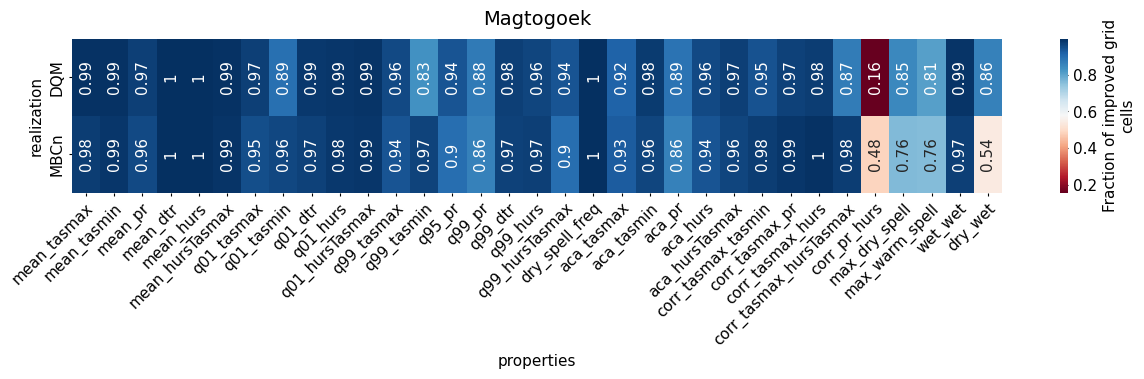

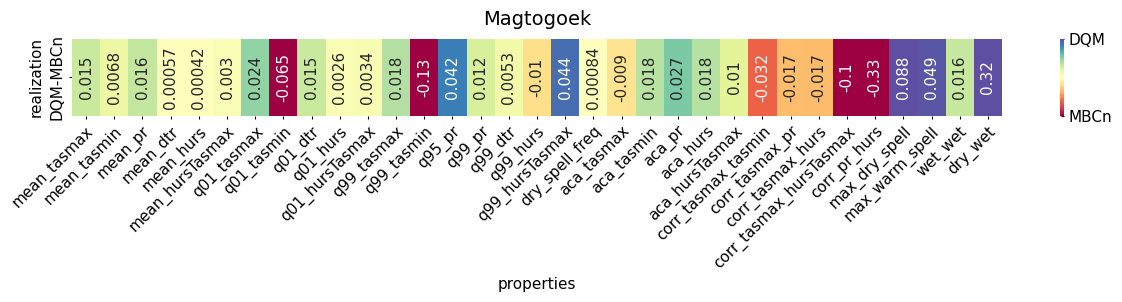

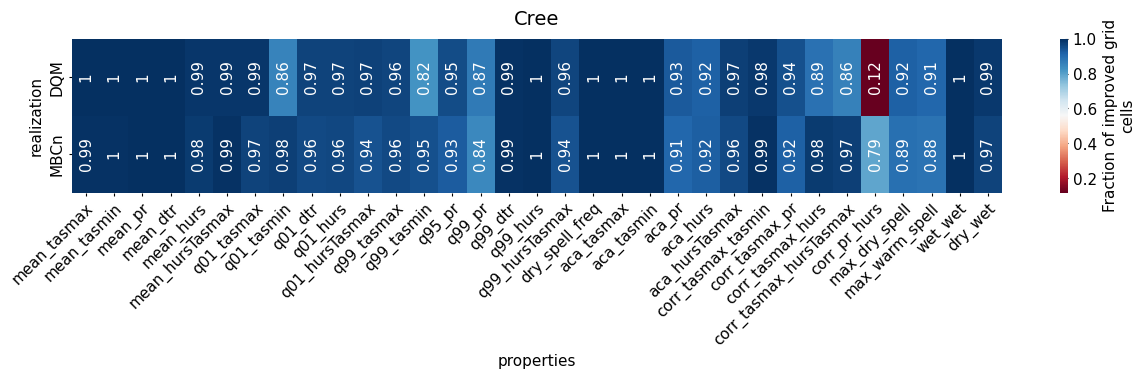

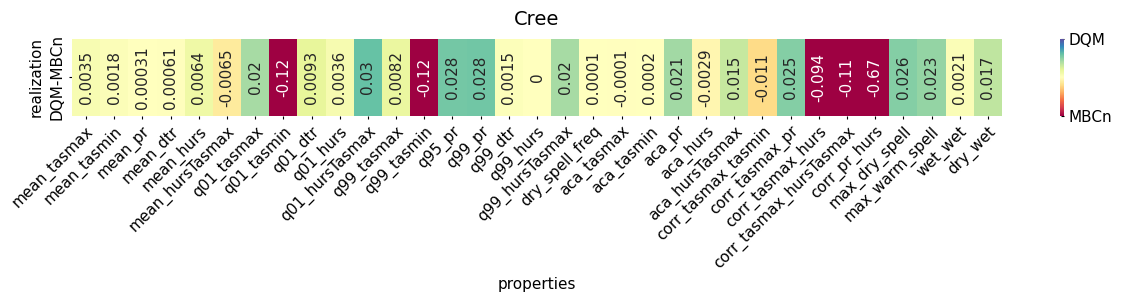

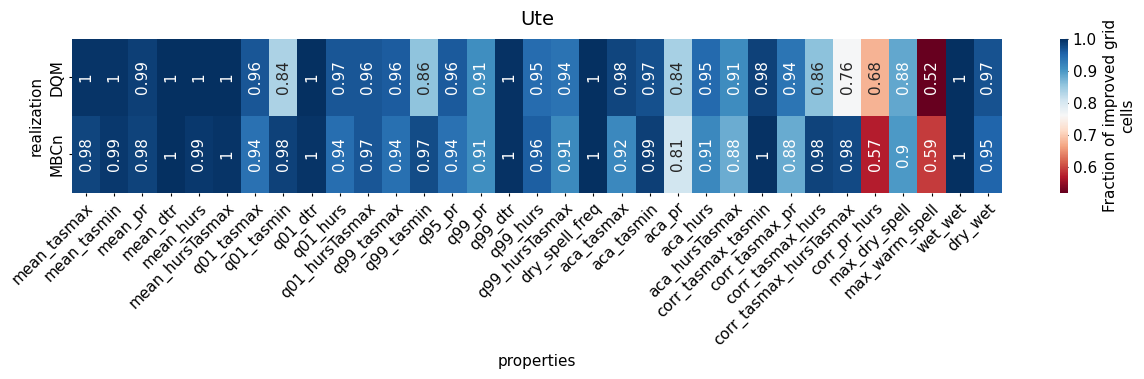

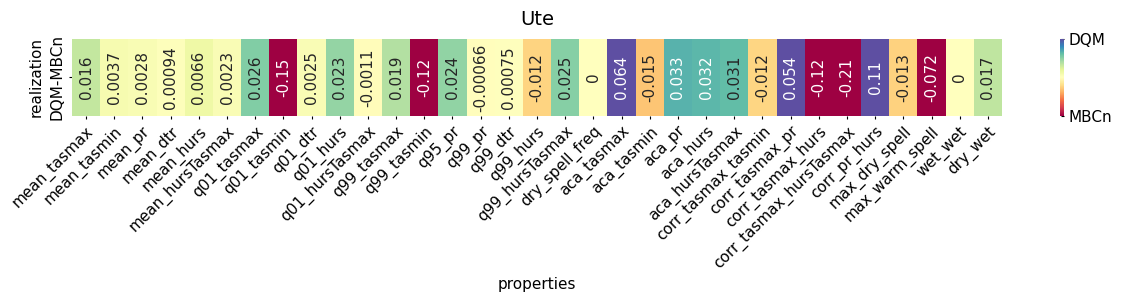

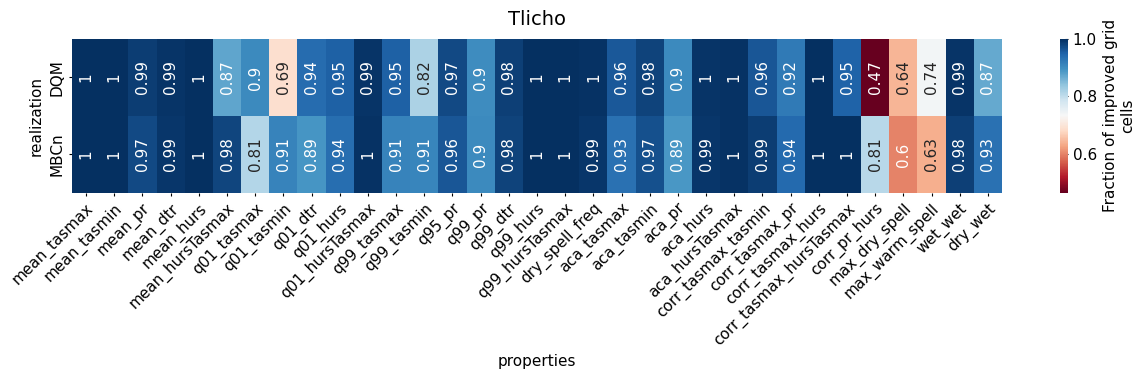

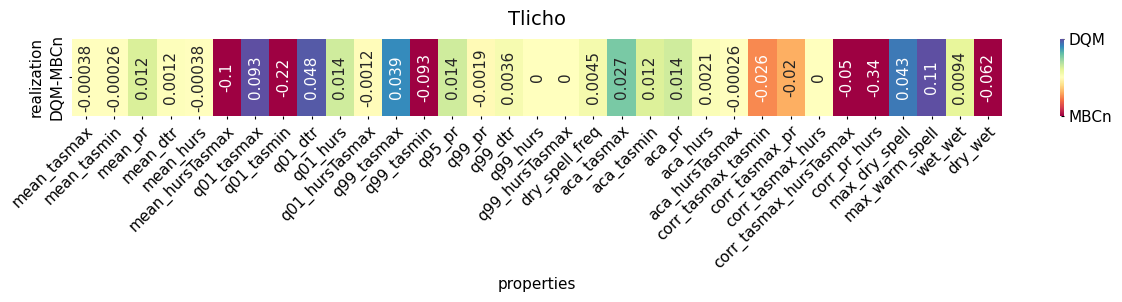

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xsdba/measures.py:283: RuntimeWarning: Mean of empty slice
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python

In [5]:
for r in ['Magtogoek','Cree','Ute','Tlicho']:

    imp_dqm=pcat.search(domain=r, bias_adjust_project='DQM', processing_level='imp').to_dataset()
    imp_mbcn=pcat.search(domain=r, bias_adjust_project='MBCn', processing_level='imp').to_dataset()

    imp_dqm=imp_dqm.expand_dims(realization=['DQM'])
    imp_mbcn=imp_mbcn.expand_dims(realization=['MBCn'])
    ds_imp= xr.concat([imp_dqm, imp_mbcn], dim='realization')
    ds_imp=ds_imp.sel(properties=["mean_tasmax","mean_tasmin","mean_pr","mean_dtr","mean_hurs","mean_hursTasmax","q01_tasmax","q01_tasmin","q01_dtr","q01_hurs","q01_hursTasmax","q99_tasmax","q99_tasmin","q95_pr","q99_pr","q99_dtr","q99_hurs","q99_hursTasmax","dry_spell_freq","aca_tasmax","aca_tasmin","aca_pr","aca_hurs","aca_hursTasmax","corr_tasmax_tasmin","corr_tasmax_pr","corr_tasmax_hurs","corr_tasmax_hursTasmax","corr_pr_hurs","max_dry_spell","max_warm_spell","wet_wet","dry_wet",])
    ds_imp=ds_imp.drop_vars('rotated_pole')
    
    ax=fg.heatmap(ds_imp,plot_kw={'annot':True, 'annot_kws':{"rotation": 90}}, fig_kw={'figsize':(15,2)})
    ax.set_title(r)

    diff= ds_imp.sel(realization='DQM') - ds_imp.sel(realization='MBCn')
    diff=diff.expand_dims(realization=['DQM-MBCn'])
    vmin=-0.05
    vmax=0.05
    ax=fg.heatmap(diff,plot_kw={'annot':True, 'annot_kws':{"rotation": 90}, 'vmin':vmin,'vmax':vmax},cmap="Spectral", fig_kw={'figsize':(15,1)})
    ax.figure.axes[1].set_yticks([vmin,vmax], labels=["MBCn", "DQM"])
    ax.set_title(r)
#M: 
#DQM is best for mean_pr

In [6]:
def maps(option_id, option_var, var_group):
    "Load properties and measures and plot them. var_group bc of bug divergent"
    
    # get data from catalogue
    prop_sim = pcat.search(id= option_id, processing_level='sim-prop',  variable=option_var).to_dask()
    prop_scen = pcat.search(id= option_id, processing_level='scen-prop',  variable=option_var).to_dask()[option_var]
    meas_sim_prop = pcat.search(id=option_id, processing_level='sim-meas',variable=option_var).to_dask()[option_var]
    meas_scen_prop = pcat.search(id=option_id, processing_level='scen-meas', variable=option_var).to_dask()[option_var]

    prop_ref = pcat.search( processing_level=['ref-prop' ],
                           domain=prop_sim.attrs['cat:domain'], 
                           bias_adjust_project=prop_sim.attrs['cat:bias_adjust_project'],
                           variable=option_var).to_dask()[option_var]
    prop_sim=prop_sim[option_var]

    
    #transpose
    if list(prop_sim.sizes.keys())[0]=='rlon':
        prop_ref=prop_ref.transpose()
        prop_sim=prop_sim.transpose()
        prop_scen=prop_scen.transpose()
        meas_sim_prop=meas_sim_prop.transpose()
        meas_scen_prop=meas_scen_prop.transpose()
    
    prop_long_name=prop_sim.attrs['long_name'] 
    meas_long_name=meas_sim_prop.attrs['long_name'] 
    # change units
    if prop_ref.attrs['units']=='kg m-2 s-1':
        prop_ref = xc.core.units.convert_units_to(prop_ref, 'mm d-1', context='hydro')
        prop_sim = xc.core.units.convert_units_to(prop_sim, 'mm d-1', context='hydro')
        prop_scen = xc.core.units.convert_units_to(prop_scen, 'mm d-1', context='hydro')
        meas_sim_prop = xc.core.units.convert_units_to(meas_sim_prop, 'mm d-1', context='hydro')
        meas_scen_prop = xc.core.units.convert_units_to(meas_scen_prop, 'mm d-1', context='hydro')
        
    if prop_ref.attrs['units']=='K':
        prop_ref = xc.core.units.convert_units_to(prop_ref, 'degC')
        prop_sim = xc.core.units.convert_units_to(prop_sim, 'degC')
        prop_scen = xc.core.units.convert_units_to(prop_scen, 'degC')
        
    #set colormap
    maxi_prop = max(prop_ref.max().values, prop_scen.max().values, prop_sim.max().values)
    mini_prop = min(prop_ref.min().values, prop_scen.min().values, prop_sim.min().values)
    maxi_meas = float(max(abs(meas_scen_prop).max().values, abs(meas_sim_prop).max().values))

    #plot
    fig = plt.figure(figsize=(15, 8))
    map_proj = ccrs.RotatedPole(pole_longitude=87.59703063964844,
                          pole_latitude=31.758316040039062,
                         )
    map_proj=ccrs.LambertConformal()
    gs = gridspec.GridSpec(4, 3)
    ax0= fig.add_subplot(gs[1:3,0],projection=map_proj)
    ax1= fig.add_subplot(gs[:2,1],projection=map_proj)
    ax2= fig.add_subplot(gs[:2,2],projection=map_proj)
    ax3= fig.add_subplot(gs[2:,1],projection=map_proj)
    ax4= fig.add_subplot(gs[2:,2],projection=map_proj)

    plot_kw_prop=dict(add_colorbar=False,vmin=float(mini_prop),vmax=float(maxi_prop))
    plot_kw_meas=dict(add_colorbar=False, vmin=-maxi_meas,vmax=maxi_meas)
    features={ 'lakes':{'scale':'110m', 'edgecolor':'black', 'facecolor':'none'},'coastline':{'scale':'50m'}}
    #plot
    # deep copy until bug is fix TODO
    fg.gridmap(prop_ref, ax=ax0, plot_kw=copy.deepcopy(plot_kw_prop), features=copy.deepcopy(features))
    fg.gridmap(prop_sim, ax=ax1, plot_kw=copy.deepcopy(plot_kw_prop), features=copy.deepcopy(features))
    fg.gridmap(prop_scen, ax=ax3, plot_kw=copy.deepcopy(plot_kw_prop), features=copy.deepcopy(features))
    fg.gridmap(meas_sim_prop, ax=ax2, plot_kw=copy.deepcopy(plot_kw_meas),cmap=f"{var_group}_div", features=copy.deepcopy(features))
    fg.gridmap(meas_scen_prop, ax=ax4, plot_kw=copy.deepcopy(plot_kw_meas),cmap=f"{var_group}_div", features=copy.deepcopy(features))
    #prop colorbar
    fig.subplots_adjust(bottom=0.1)
    cbar_ax = fig.add_axes([0.15, 0.01, 0.45, 0.03])
    cb1=fig.colorbar(ax0.get_children()[0], cax=cbar_ax,orientation='horizontal')
    cb1.set_label(label=f"{prop_long_name} ({prop_sim.attrs['units']})",size=15)
    cb1.ax.tick_params(axis='x', direction='out')
    cb1.outline.set_visible(False)
    
    #meas colorbar
    fig.subplots_adjust(bottom=0.1)
    cbar_ax = fig.add_axes([0.68, 0.01, 0.25, 0.03])
    cb2=fig.colorbar(ax2.get_children()[0], cax=cbar_ax,orientation='horizontal')
    cb2.set_label(label=f"{meas_long_name} ({meas_sim_prop.attrs['units']})",size=15)
    
    cb2.ax.tick_params(axis='x', direction='out')
    cb2.outline.set_visible(False)

    rmse_sim= np.sqrt(np.nanmean((
        prop_sim.stack(loc=['rlat','rlon']).values  -
        prop_ref.stack(loc=['rlat','rlon']).values) ** 2))

    rmse_scen= np.sqrt(np.nanmean((
        prop_scen.stack(loc=['rlat','rlon']).values  -
        prop_ref.stack(loc=['rlat','rlon']).values) ** 2))
    
    
    fs=15
    ax0.set_title(r'a) reference', fontsize=fs)
    ax1.set_title(r'b) original', fontsize=fs)
    prop_sim.attrs['units']=prop_sim.attrs['units'].replace('mm d-1', 'mm/d')
    prop_scen.attrs['units']=prop_scen.attrs['units'].replace('mm d-1', 'mm/d')
    ax2.set_title(f"c) original \n RMSE={rmse_sim:.2f} {prop_sim.attrs['units']}",fontsize=fs)
    #ax2.set_title(f"c) original",fontsize=fs)

    ax3.set_title(r'd) bias-adjusted', fontsize=fs)
    ax4.set_title(f"e) bias-adjusted \n RMSE={rmse_scen:.2f} {prop_scen.attrs['units']}",fontsize=fs)
    #ax4.set_title(f"e) bias-adjusted",fontsize=fs)
    fig.tight_layout(pad=5.0)
    return fig,[ax0,ax1,ax2,ax3,ax4], [cb1,cb2]

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/tmp/ipykernel_1933156/3698165183.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layo

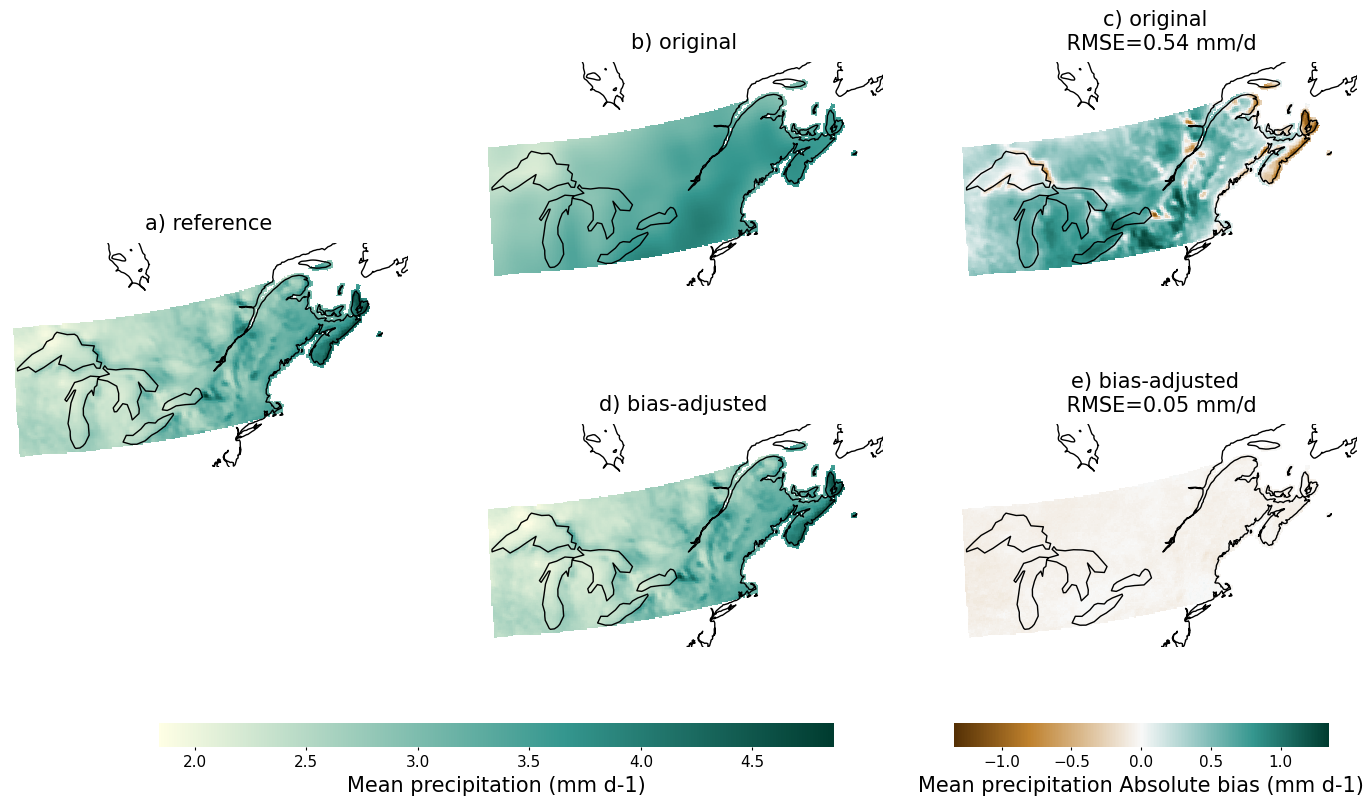

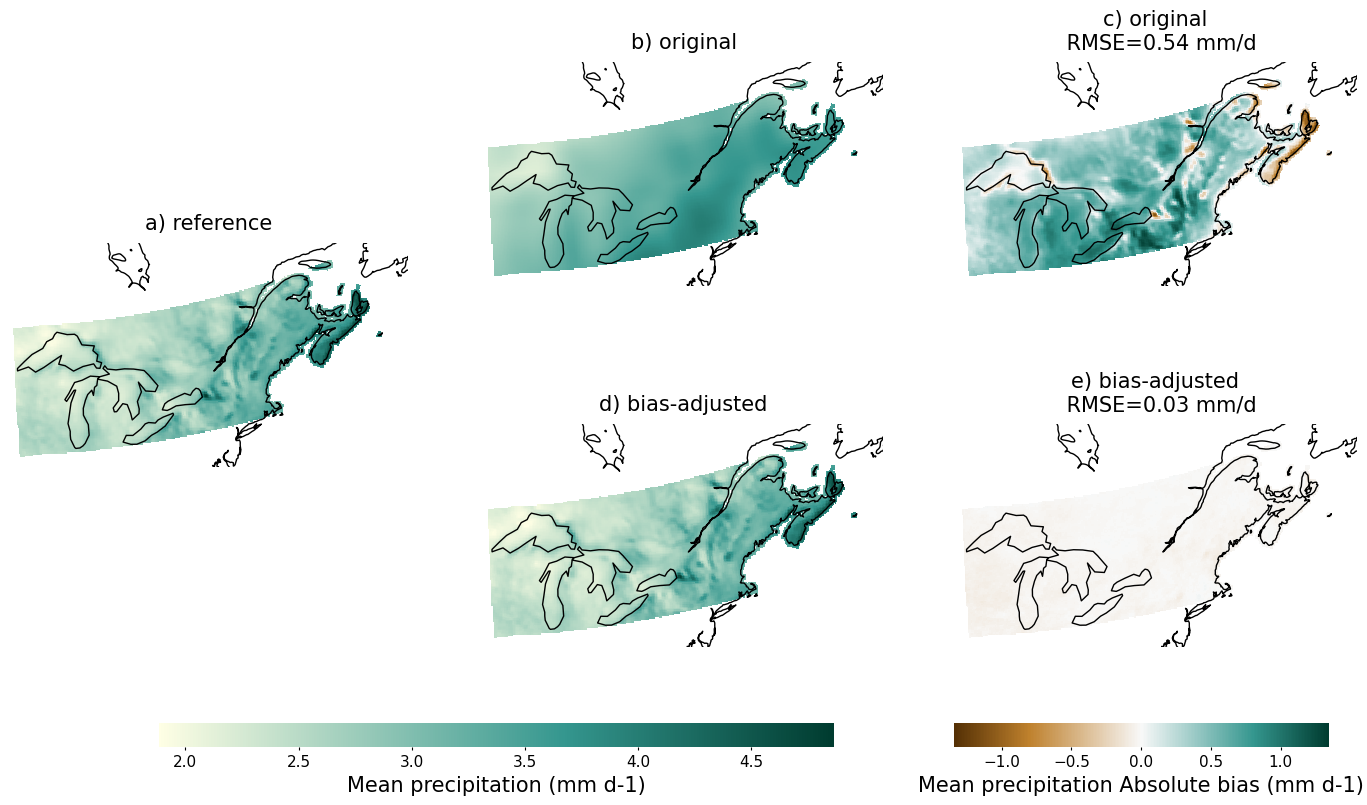

In [7]:

maps('MBCn_CMIP6_ScenarioMIP_MRI_MRI-ESM2-0_ssp370_r1i1p1f1_Magtogoek', 'mean_pr',var_group='prec');
maps('DQM_CMIP6_ScenarioMIP_MRI_MRI-ESM2-0_ssp370_r1i1p1f1_Magtogoek', 'mean_pr',var_group='prec');

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


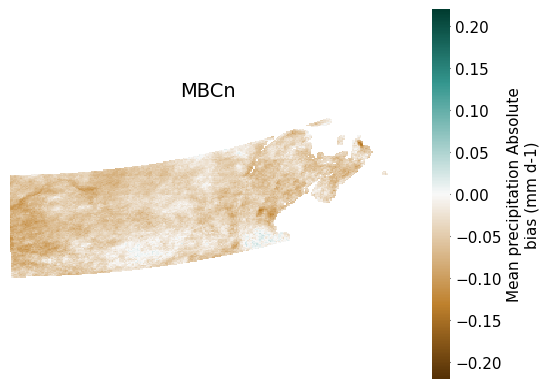

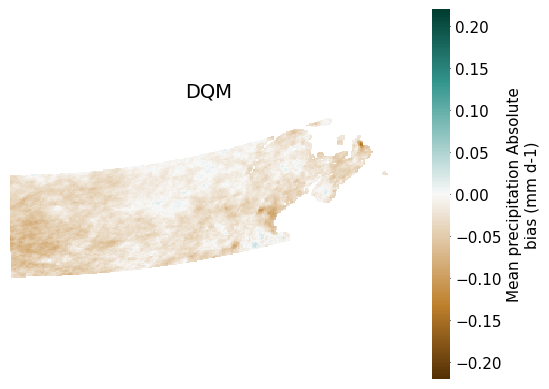

In [8]:
# same as above but both scen_meas on same cbar
option_var='mean_pr'
for option_id in ['MBCn_CMIP6_ScenarioMIP_MRI_MRI-ESM2-0_ssp370_r1i1p1f1_Magtogoek',
          'DQM_CMIP6_ScenarioMIP_MRI_MRI-ESM2-0_ssp370_r1i1p1f1_Magtogoek']:
    meas_scen_prop = pcat.search(id=option_id, processing_level='scen-meas', variable=option_var,).to_dask()[option_var]
    ax=fg.gridmap(meas_scen_prop, plot_kw=dict(vmin=-0.22, vmax=0.22), cmap='prec_div', transform=ccrs.LambertConformal(),
                  features= { 'lakes':{'scale':'110m', 'edgecolor':'black', 'facecolor':'none'},'coastline':{'scale':'50m'}}
                 )
    ax.set_title(option_id.split('_')[0])

# spell

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/tmp/ipykernel_1933156/3698165183.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layo

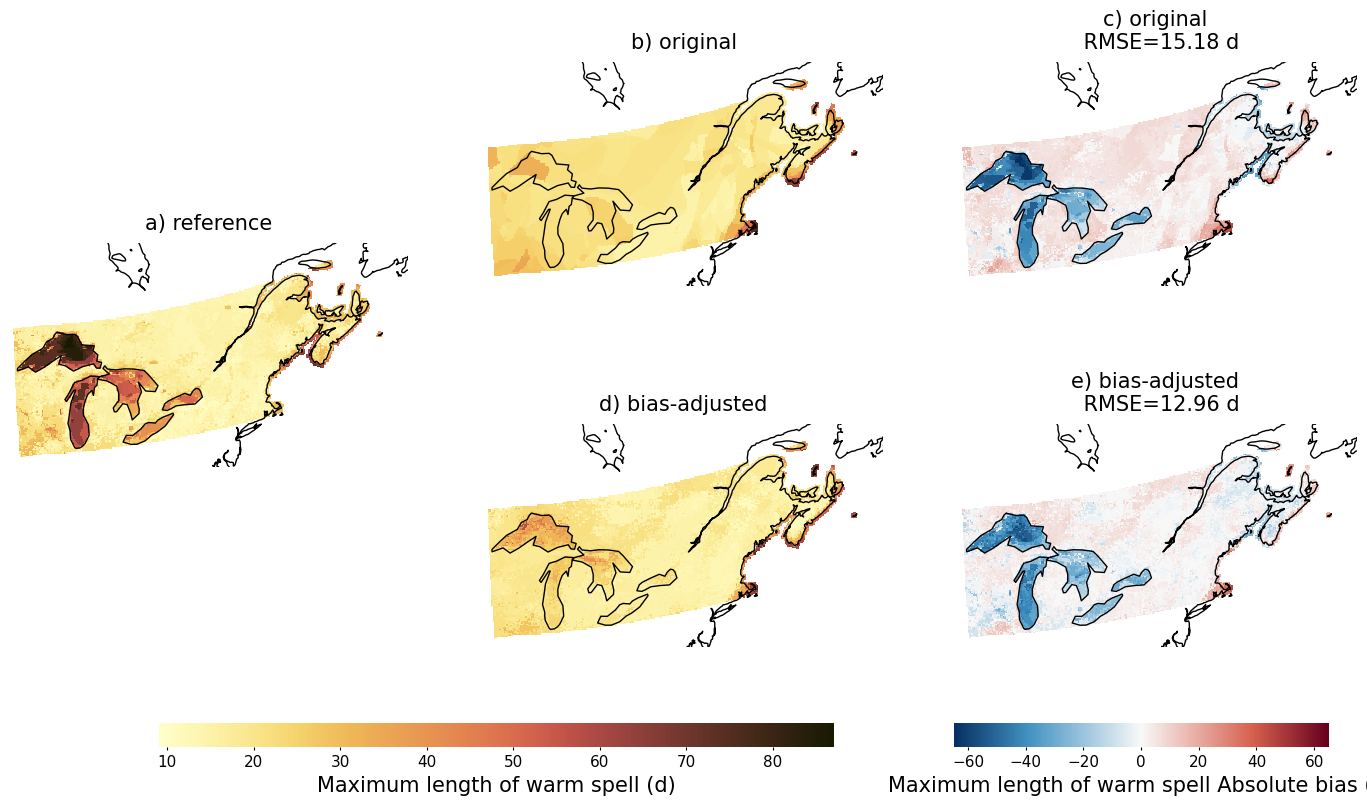

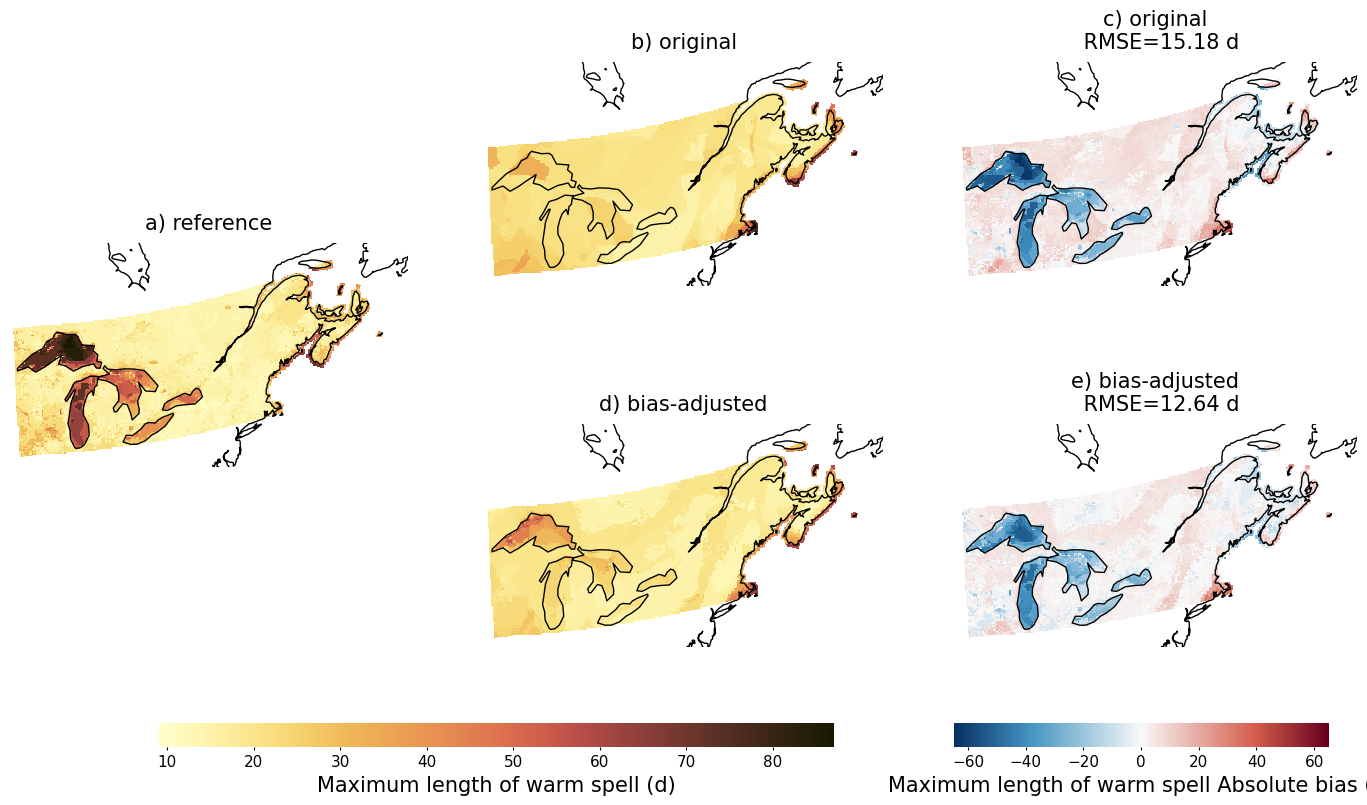

In [9]:
maps('MBCn_CMIP6_ScenarioMIP_MRI_MRI-ESM2-0_ssp370_r1i1p1f1_Magtogoek', "max_warm_spell", 'temp');
maps('DQM_CMIP6_ScenarioMIP_MRI_MRI-ESM2-0_ssp370_r1i1p1f1_Magtogoek', "max_warm_spell", 'temp');

# humidex

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarn

Text(0.5, 1.0, 'DQM - MBCn')

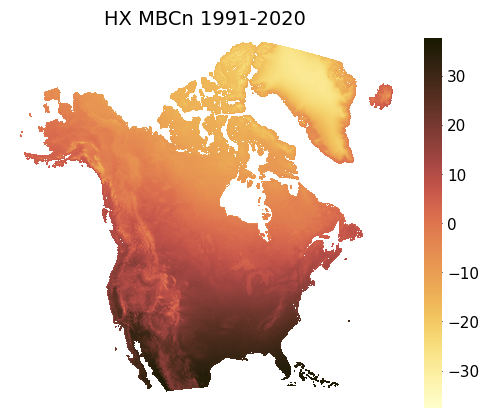

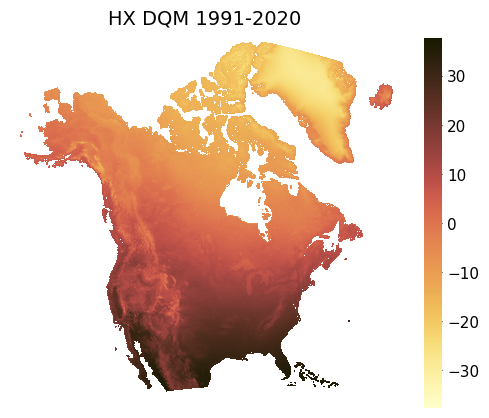

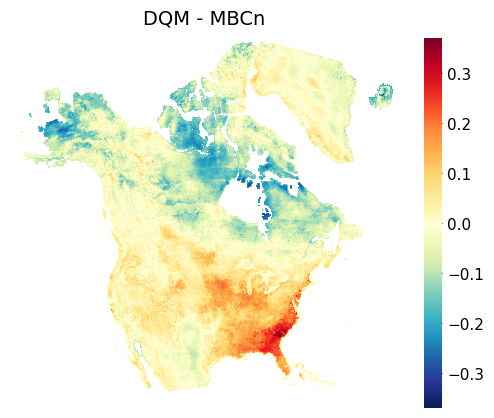

In [10]:
hx_mbcn=pcat.search(bias_adjust_project='MBCn',variable='hx').to_dataset()
hx_dqm=pcat.search(bias_adjust_project='DQM',variable='hx').to_dataset()
hx_ref=pcat.search(source='CaSR',variable='hx').to_dataset()

hx_mbcn=hx_mbcn.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)
hx_ref=hx_ref.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)

hx_mbcn=hx_mbcn.sel(time=slice('1991','2020'))#.isel(lat=slice(None,-1))
hx_dqm=hx_dqm.sel(time=slice('1991','2020'))
hx_ref=hx_ref.sel(time=slice('1991','2020'))#.isel(lat=slice(None,-1))

hx_mbcn=hx_mbcn.hx.chunk({'time':-1})
hx_dqm=hx_dqm.hx.chunk({'time':-1})
hx_ref=hx_ref.hx.chunk({'time':-1})

ax=fg.gridmap(hx_mbcn.mean(dim='time'), projection=ccrs.LambertConformal(), cmap='temp_seq')
ax.set_title('HX MBCn 1991-2020')
ax=fg.gridmap(hx_dqm.mean(dim='time'), projection=ccrs.LambertConformal(), cmap='temp_seq')
ax.set_title('HX DQM 1991-2020')

ax=fg.gridmap(hx_dqm.mean(dim='time')-hx_mbcn.mean(dim='time'), projection=ccrs.LambertConformal(), cmap='misc_div')
ax.set_title('DQM - MBCn')

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/e

Text(0.5, 1.0, 'RMSE DQM-MBCn hx')

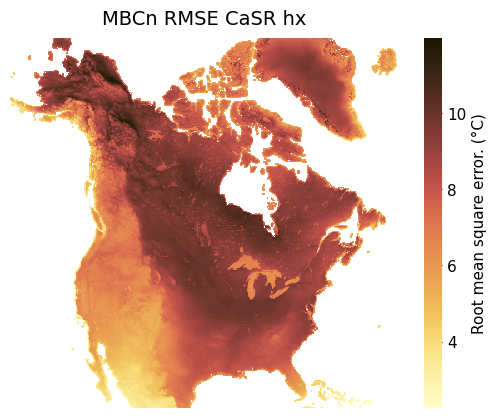

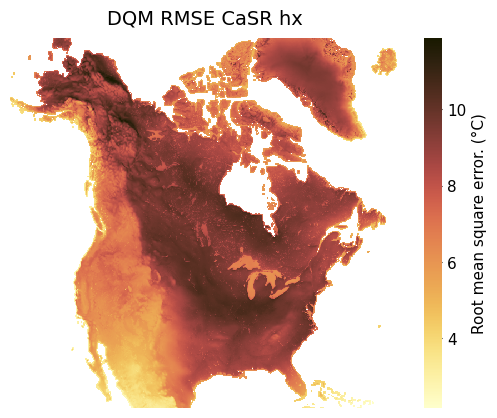

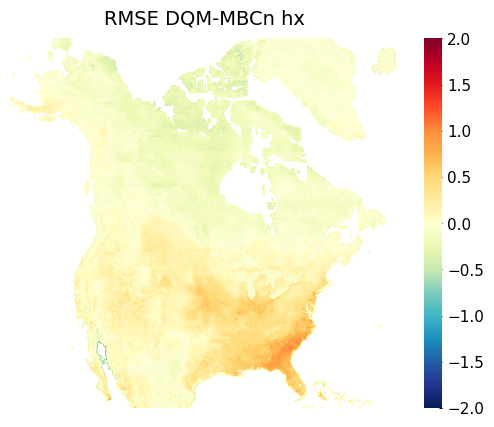

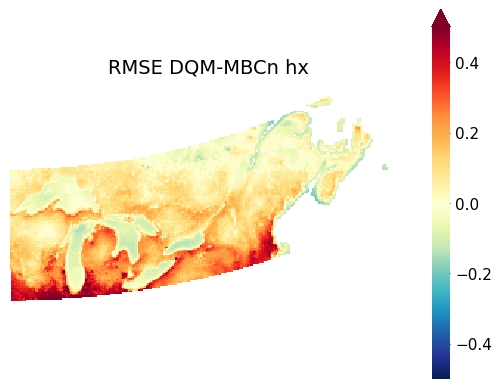

In [12]:
#rmse

rmse_mbcn= xa.measures.rmse(hx_mbcn, hx_ref)
rmse_dqm= xa.measures.rmse(hx_dqm, hx_ref)

ax=fg.gridmap(rmse_mbcn, cmap='temp_seq', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('MBCn RMSE CaSR hx')

ax=fg.gridmap(rmse_dqm, cmap='temp_seq', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('DQM RMSE CaSR hx')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff,cmap='misc_div',plot_kw={'vmin':-2, 'vmax':2}, projection=ccrs.LambertConformal(), features=['coastline'])
ax.set_title('RMSE DQM-MBCn hx')

diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff,cmap='misc_div',plot_kw={'vmin':-0.5, 'vmax':0.5}, projection=ccrs.LambertConformal(), features=['coastline'])
ax.set_title('RMSE DQM-MBCn hx')
# Rouge = MBCn est meilleur

## HX35

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/e

Text(0.5, 1.0, 'DQM-MBCn HX35 RMSE')

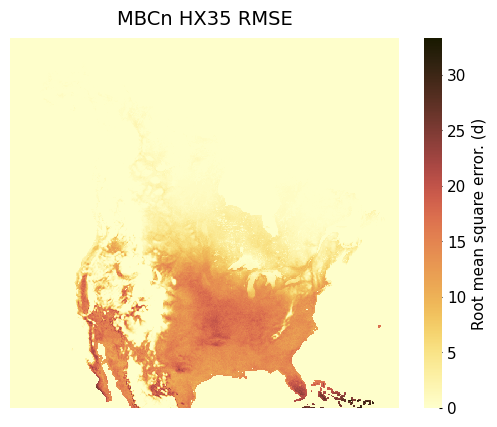

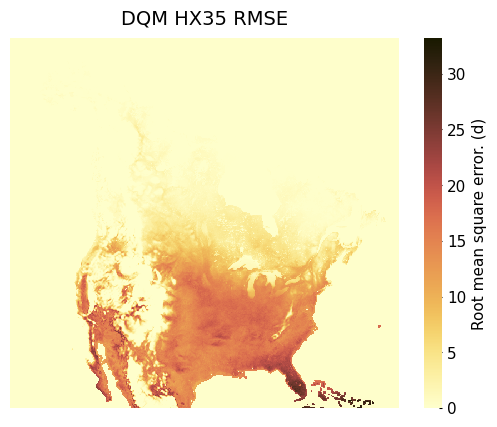

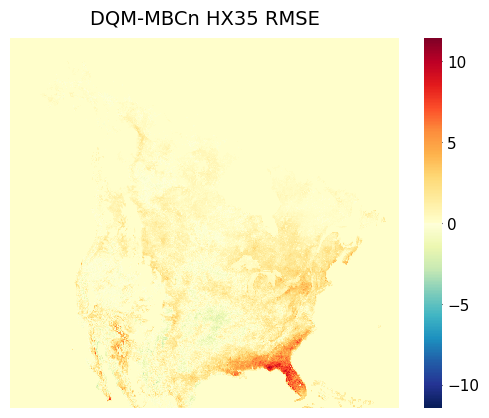

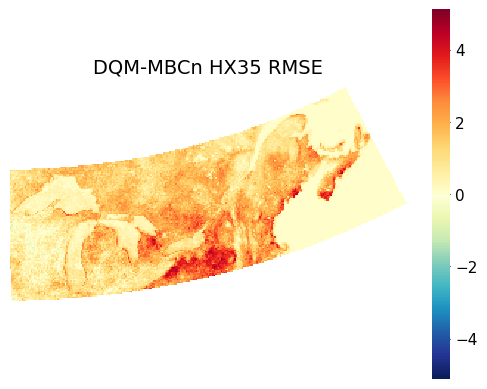

In [13]:
hx35_mbcn=pcat.search(bias_adjust_project='MBCn',variable='hx35').to_dataset().hx35
hx35_dqm=pcat.search(bias_adjust_project='DQM',variable='hx35').to_dataset().hx35
hx35_ref=pcat.search(source='CaSR',variable='hx35').to_dataset().hx35

hx35_mbcn=hx35_mbcn.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)
hx35_ref=hx35_ref.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)

hx35_mbcn=hx35_mbcn.sel(time=slice('1991','2020')).chunk(dict(time=-1))
hx35_dqm=hx35_dqm.sel(time=slice('1991','2020')).chunk({'time':-1})
hx35_ref=hx35_ref.sel(time=slice('1991','2020')).chunk(dict(time=-1))


rmse_mbcn= xa.measures.rmse(hx35_mbcn, hx35_ref)
rmse_dqm= xa.measures.rmse(hx35_dqm, hx35_ref)

ax=fg.gridmap(rmse_mbcn, cmap='temp_seq', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('MBCn HX35 RMSE')

ax=fg.gridmap(rmse_dqm, cmap='temp_seq', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('DQM HX35 RMSE')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, cmap='misc_div', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('DQM-MBCn HX35 RMSE')


diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, cmap='misc_div', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('DQM-MBCn HX35 RMSE')


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/s

Text(0.5, 1.0, 'DQM-MBCn hx30 RMSE')

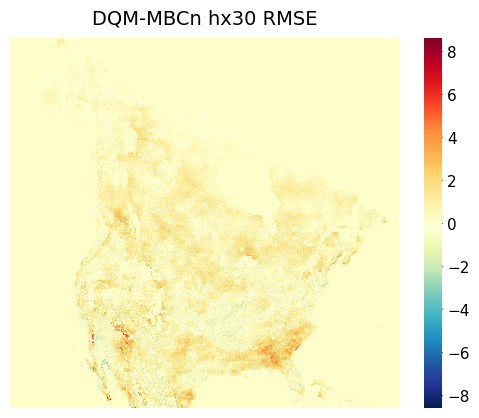

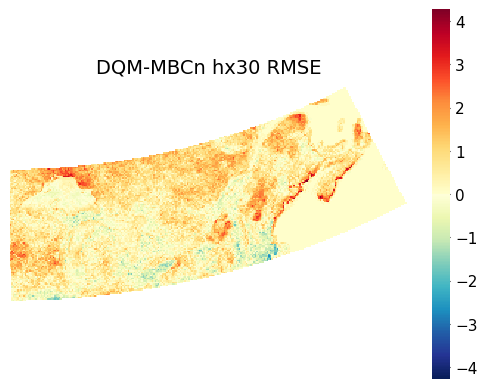

In [14]:
hx30_mbcn=pcat.search(bias_adjust_project='MBCn',variable='hx30').to_dataset().hx30
hx30_dqm=pcat.search(bias_adjust_project='DQM',variable='hx30').to_dataset().hx30
hx30_ref=pcat.search(source='CaSR',variable='hx30').to_dataset().hx30

hx30_mbcn=hx30_mbcn.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)
hx30_ref=hx30_ref.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)

hx30_mbcn=hx30_mbcn.sel(time=slice('1991','2020')).chunk(dict(time=-1))
hx30_dqm=hx30_dqm.sel(time=slice('1991','2020')).chunk({'time':-1})
hx30_ref=hx30_ref.sel(time=slice('1991','2020')).chunk(dict(time=-1))


rmse_mbcn= xa.measures.rmse(hx30_mbcn, hx30_ref)
rmse_dqm= xa.measures.rmse(hx30_dqm, hx30_ref)

# ax=fg.gridmap(rmse_mbcn, cmap='temp_seq')
# ax.set_title('MBCn hx30 RMSE')

# ax=fg.gridmap(rmse_dqm, cmap='temp_seq')
# ax.set_title('DQM hx30 RMSE')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, cmap='misc_div', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('DQM-MBCn hx30 RMSE')


diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, cmap='misc_div', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('DQM-MBCn hx30 RMSE')


## thi

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/s

Text(0.5, 1.0, 'DQM-MBCn thi RMSE')

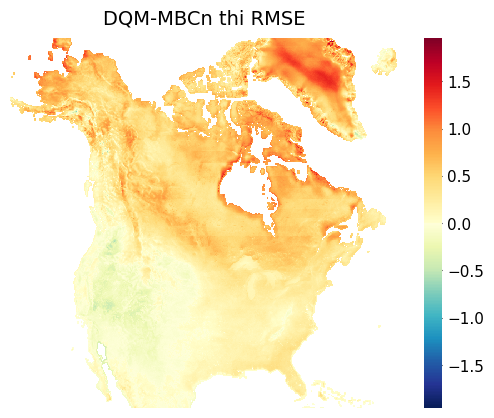

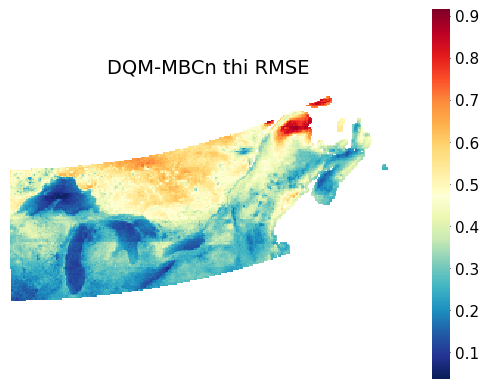

In [15]:
thi_mbcn=pcat.search(bias_adjust_project='MBCn',variable='thi').to_dataset().thi
thi_dqm=pcat.search(bias_adjust_project='DQM',variable='thi').to_dataset().thi
thi_ref=pcat.search(source='CaSR',variable='thi').to_dataset().thi

thi_mbcn=thi_mbcn.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)
thi_ref=thi_ref.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)

thi_mbcn=thi_mbcn.sel(time=slice('1991','2020')).chunk(dict(time=-1))
thi_dqm=thi_dqm.sel(time=slice('1991','2020')).chunk({'time':-1})
thi_ref=thi_ref.sel(time=slice('1991','2020')).chunk(dict(time=-1))


rmse_mbcn= xa.measures.rmse(thi_mbcn, thi_ref)
rmse_dqm= xa.measures.rmse(thi_dqm, thi_ref)

# ax=fg.gridmap(rmse_mbcn, cmap='temp_seq')
# ax.set_title('MBCn thi RMSE')

# ax=fg.gridmap(rmse_dqm, cmap='temp_seq')
# ax.set_title('DQM thi RMSE')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, cmap='misc_div', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('DQM-MBCn thi RMSE')


diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, cmap='misc_div', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('DQM-MBCn thi RMSE')


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:962: UserWarning: Rotated pole not found. Specify a transform if necessary.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/s

Text(0.5, 1.0, 'DQM-MBCn this RMSE')

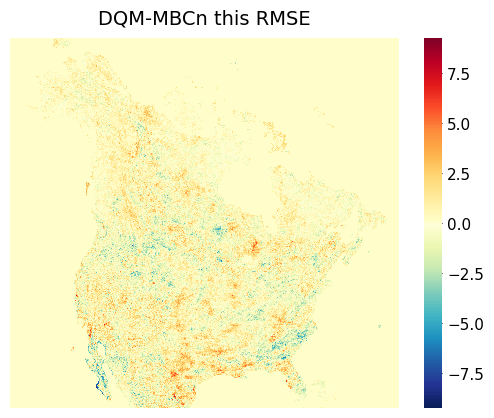

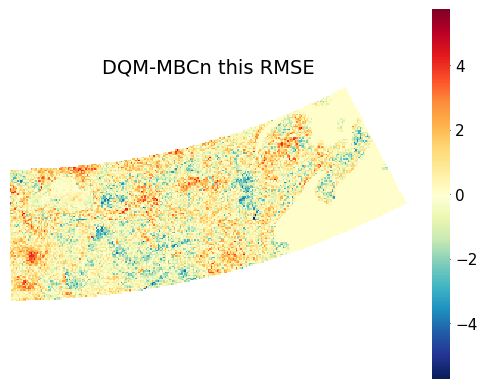

In [16]:
this_mbcn=pcat.search(bias_adjust_project='MBCn',variable='thi_spell_total_length').to_dataset().thi_spell_total_length
this_dqm=pcat.search(bias_adjust_project='DQM',variable='thi_spell_total_length').to_dataset().thi_spell_total_length
this_ref=pcat.search(source='CaSR',variable='thi_spell_total_length').to_dataset().thi_spell_total_length

this_mbcn=this_mbcn.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)
this_ref=this_ref.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)

this_mbcn=this_mbcn.sel(time=slice('1991','2020')).chunk(dict(time=-1))
this_dqm=this_dqm.sel(time=slice('1991','2020')).chunk({'time':-1})
this_ref=this_ref.sel(time=slice('1991','2020')).chunk(dict(time=-1))


rmse_mbcn= xa.measures.rmse(this_mbcn, this_ref)
rmse_dqm= xa.measures.rmse(this_dqm, this_ref)

# ax=fg.gridmap(rmse_mbcn, cmap='temp_seq')
# ax.set_title('MBCn this RMSE')

# ax=fg.gridmap(rmse_dqm, cmap='temp_seq')
# ax.set_title('DQM this RMSE')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, cmap='misc_div', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('DQM-MBCn this RMSE')


diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, cmap='misc_div', features=['coastline'], projection=ccrs.LambertConformal())
ax.set_title('DQM-MBCn this RMSE')

# solid_prcptot

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustr

Text(0.5, 1.0, 'DQM-MBCn solid pr RMSE')

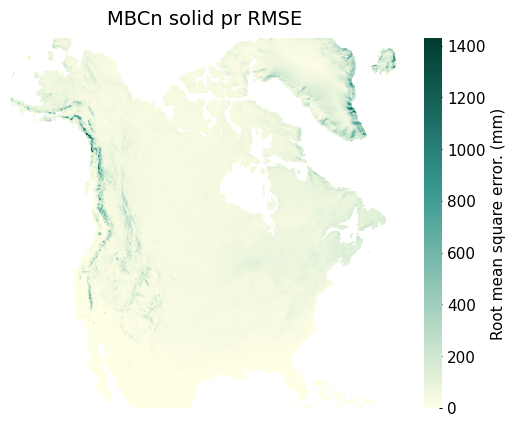

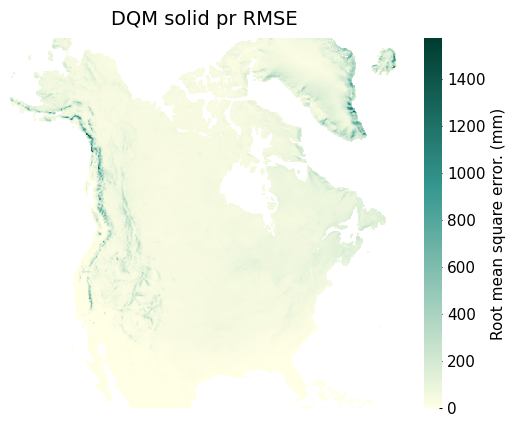

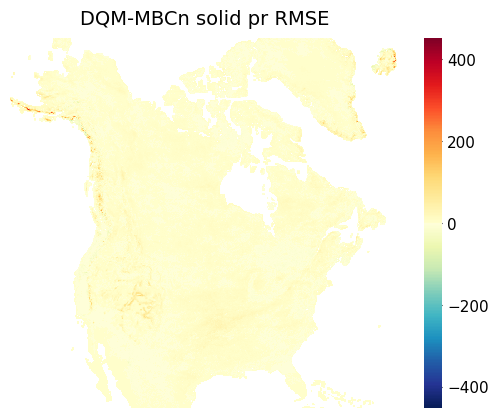

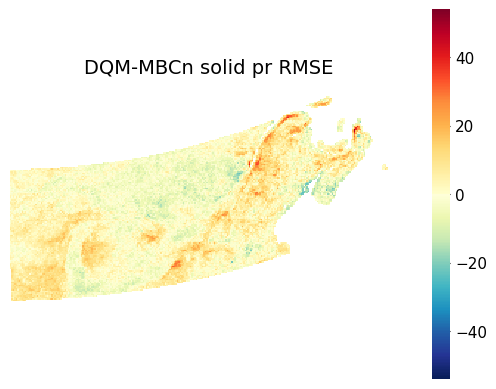

In [17]:
ds_mbcn=pcat.search(bias_adjust_project='MBCn',variable=['tasmax', 'tasmin','pr']).to_dataset()
ds_dqm=pcat.search(bias_adjust_project='DQM',variable=['tasmax', 'tasmin','pr']).to_dataset()
ds_ref=pcat.search(source='CaSR',variable=['tasmax', 'tasmin','pr']).to_dataset()
ds_ref=ds_ref.convert_calendar('noleap')

ds_mbcn=ds_mbcn.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)
ds_ref=ds_ref.sel(rlat=slice(hx_dqm.rlat.min().values,hx_dqm.rlat.max().values),
                    rlon=slice(hx_dqm.rlon.min().values,hx_dqm.rlon.max().values),)

ds_mbcn=ds_mbcn.sel(time=slice('1991','2020')).chunk({'time':-1})
ds_dqm=ds_dqm.sel(time=slice('1991','2020')).chunk({'time':-1})
ds_ref=ds_ref.sel(time=slice('1991','2020')).chunk({'time':-1})


ds_mbcn['tas']=xc.convert.mean_temperature_from_max_and_min(ds=ds_mbcn)
ds_dqm['tas']=xc.convert.mean_temperature_from_max_and_min(ds=ds_dqm)
ds_ref['tas']=xc.convert.mean_temperature_from_max_and_min(ds=ds_ref)

spr_mbcn=xc.atmos.solid_precip_accumulation(ds=ds_mbcn)
spr_dqm=xc.atmos.solid_precip_accumulation(ds=ds_dqm)
spr_ref=xc.atmos.solid_precip_accumulation(ds=ds_ref)


rmse_mbcn= xa.measures.rmse(spr_mbcn, spr_ref)
rmse_dqm= xa.measures.rmse(spr_dqm, spr_ref)

ax=fg.gridmap(rmse_mbcn, cmap='prec_seq')
ax.set_title('MBCn solid pr RMSE')

ax=fg.gridmap(rmse_dqm, cmap='prec_seq')
ax.set_title('DQM solid pr RMSE')

diff=rmse_dqm-rmse_mbcn

ax=fg.gridmap(diff, cmap='misc_div')
ax.set_title('DQM-MBCn solid pr RMSE')


diff=xs.spatial.subset(diff,**CONFIG['diagregion']['Magtogoek'])
ax=fg.gridmap(diff, cmap='misc_div')
ax.set_title('DQM-MBCn solid pr RMSE')
